# Mahine Learning
   - Supervised learning(Data(x) + Lables(y))
       - Regression
            - Simple Linear Regression (data(X))
            - Multi Linear Regression (multiple x)
            - polynominal Regression
       - Classfication (01,TF, Cat/Dog)
            - Binary Classfication (Yes/no)
            - Multi-class Classfication (multiple classes)
   - Unsupervised Leaning(Data)
            - Clusters
            -----
   - Semi Supervised Learning(data + lables (Autoencoders))
   - Reiforsement Learning

In [1]:
}import pandas as pd

In [3]:
data=pd.read_csv("weight-height.csv")

In [4]:
data.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


**Simple Linear Regression**
 - We only have 1 Input Coloum

In [7]:
data.Gender.replace({"Male":1,"Female":0},inplace=True)

/tmp/ipykernel_615/2917397395.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.Gender.replace({"Male":1,"Female":0},inplace=True)


In [8]:
data.corr()

,Gender,Height,Weight
Gender,1.000000,0.691072,0.796723
Height,0.691072,1.000000,0.924756
Weight,0.796723,0.924756,1.000000


In [10]:
X=data[["Height"]]
y=data[["Weight"]]

In [12]:
X,y

(         Height
 0     73.847017
 1     68.781904
 2     74.110105
 3     71.730978
 4     69.881796
 ...         ...
 9995  66.172652
 9996  67.067155
 9997  63.867992
 9998  69.034243
 9999  61.944246
 
 [10000 rows x 1 columns],
           Weight
 0     241.893563
 1     162.310473
 2     212.740856
 3     220.042470
 4     206.349801
 ...          ...
 9995  136.777454
 9996  170.867906
 9997  128.475319
 9998  163.852461
 9999  113.649103
 
 [10000 rows x 1 columns])

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_text = train_test_split(X,y,test_size=0.30,random_state=32)

In [16]:
X_train.ndim

2

In [17]:
X_test

,Height
6252,68.687232
4684,68.829334
1731,66.398128
4742,71.929340
4521,67.042903
...,...
8014,62.715618
1074,70.123761
3063,69.883451
6487,62.266592


In [18]:
from sklearn.linear_model import LinearRegression
Lr = LinearRegression()

In [19]:
Lr.fit(X_train,y_train)

LinearRegression()

In [20]:
Lr.coef_

array([[7.69542535]])

In [21]:
Lr.intercept_

array([-349.32334861])

**Weight = 7.69(Height)+(-349.32)**

In [25]:
y_pred_train = Lr.predict(X_train)

In [31]:
from sklearn.metrics import mean_squared_error,r2_score

In [33]:
from math import sqrt
sqrt(mean_squared_error(y_train,y_pred_train))

12.235384679100555

In [35]:
r2_score(y_train,y_pred_train)#jitna 1 ky utha acha, 0 pass uthna bura

0.8539725668285365

In [37]:
y_pred_test = Lr.predict(X_test)

In [40]:
from math import sqrt
sqrt(mean_squared_error(y_text,y_pred_test))

12.180406205375089

In [41]:
r2_score(y_text,y_pred_test)#jitna 1 ky utha acha, 0 pass uthna bura

0.8577298529881874

In [46]:
def weight_pred(height):
    return Lr.predict([[height]])*0.453592

In [49]:
height_inches = float(input("Enter Your Height "))*12
print(f"""your weight is:/n{weight_pred(height_inches)}""")

Enter Your Height 5.6
your weight is:/n[[76.11692659]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


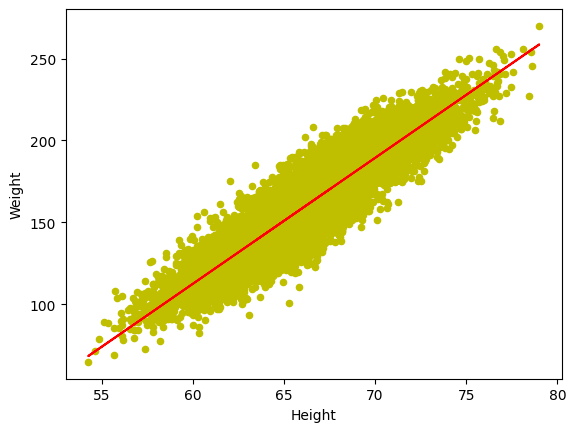

In [51]:
import matplotlib.pyplot as plt
data.plot(kind="scatter",x="Height",y="Weight",color="y")
plt.plot(X_train,y_pred_train,color="r")
plt.show()

Multi Linear Regression
- We have More then 1 input
- Linear Regression : equation = y=mx+b # when we have only 1 input
- multi Linear Regression: equation = y=m1x1+m2x2+m3x3+m4x4.....MnXn+b

In [52]:
data

,Gender,Height,Weight
0,1,73.847017,241.893563
1,1,68.781904,162.310473
2,1,74.110105,212.740856
3,1,71.730978,220.042470
4,1,69.881796,206.349801
...,...,...,...
9995,0,66.172652,136.777454
9996,0,67.067155,170.867906
9997,0,63.867992,128.475319
9998,0,69.034243,163.852461


In [61]:
# X = data.drop("Weight",axis=1)
X= data[["Gender","Height"]]
y=data[["Weight"]]

In [62]:
X

,Gender,Height
0,1,73.847017
1,1,68.781904
2,1,74.110105
3,1,71.730978
4,1,69.881796
...,...,...
9995,0,66.172652
9996,0,67.067155
9997,0,63.867992
9998,0,69.034243


In [63]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_text = train_test_split(X,y,test_size=0.30,random_state=32)

In [64]:
X_train

,Gender,Height
6029,0,62.495681
4381,1,69.699604
3696,1,70.402478
1685,1,73.507360
6272,0,65.537463
...,...,...
8444,0,62.157304
7571,0,67.757970
4030,1,71.318434
9526,0,60.096442


In [65]:
Lr.fit(X_train,y_train)

LinearRegression()

In [66]:
y_pred_train = Lr.predict(X_train)

In [68]:
sqrt(mean_squared_error(y_train,y_pred_train))

10.04810130974677

In [69]:
r2_score(y_train,y_pred_train)

0.9014656943133919

In [70]:
y_pred_test = Lr.predict(X_test)

In [72]:
sqrt(mean_squared_error(y_text,y_pred_test))

9.93050504166852

In [73]:
r2_score(y_text,y_pred_test)

0.9056474499775117

In [74]:
def weight_pred(gender,height):
    return Lr.predict([[gender,height]])*0.453592

In [77]:
gender = int(input("enter your gender: "))
height = float(input("enter your height: "))*12
print(f"""your weight is:/n{weight_pred(gender,height)}""")

enter your gender: 0
enter your height: 5.3
your weight is:/n[[61.32118375]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
